## **Import Necessary Libraries**

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **1. Set Plot Styles**

In [7]:
# Set plot styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### **2. Load dataset**

In [8]:
fake_path = r"E:\Arshdeep CL NLP Project\Dataset\raw\Fake.csv"
real_path = r"E:\Arshdeep CL NLP Project\Dataset\raw\True.csv"

In [9]:
fake_df = pd.read_csv(fake_path)
real_df = pd.read_csv(real_path)

### **3. Adding Labels**

In [10]:
# Add labels
fake_df["label"] = 0  # 0 = Fake
real_df["label"] = 1  # 1 = Real

### **4. Combining Both**

In [11]:
# Combine both
df = pd.concat([fake_df, real_df], ignore_index=True)
print(f"Dataset shape: {df.shape}")

Dataset shape: (44898, 5)


### **5. Shuffle the DataFrame**

In [12]:
# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

### **6. View the Frame**

In [13]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## **Label Distribution**

### Count of Fake vs Real

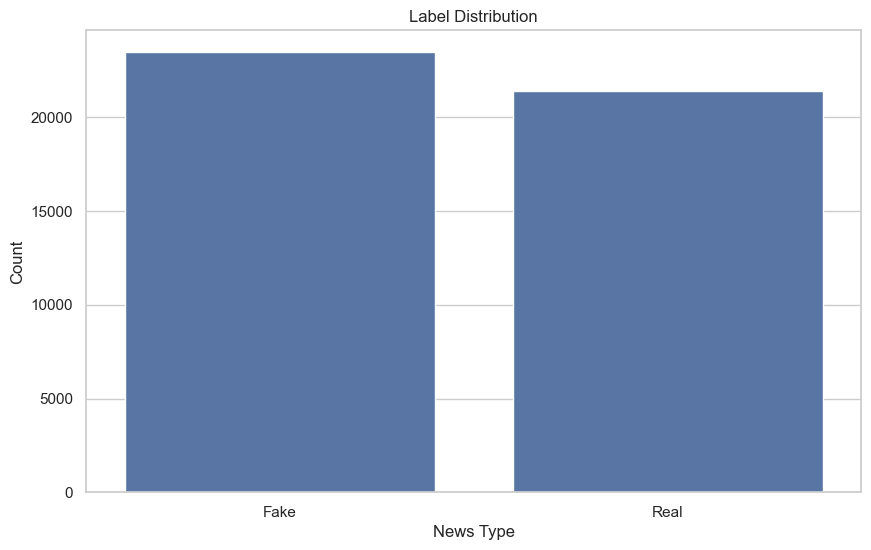

In [14]:
sns.countplot(data=df, x="label")
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title("Label Distribution")
plt.xlabel("News Type")
plt.ylabel("Count")
plt.show()

### Text Length Analysis

In [15]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

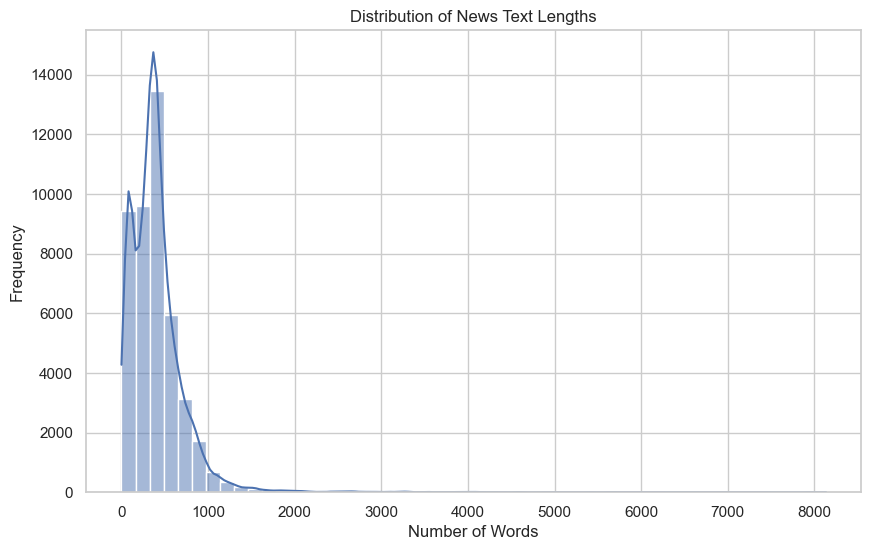

label
0    423.197905
1    385.640099
Name: text_length, dtype: float64

In [16]:
sns.histplot(df["text_length"], kde=True, bins=50)
plt.title("Distribution of News Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

df.groupby("label")["text_length"].mean() #This is average-word count per label

### Headline Duplication Check

In [17]:
print(f"Total headlines: {df['title'].nunique()} / {len(df)}")

Total headlines: 38729 / 44898


# **Word Cloud**

In [18]:
from wordcloud import WordCloud

In [19]:
fake_text = " ".join(fake_df["text"])
real_text = " ".join(real_df["text"])

In [20]:
wCloudfake = WordCloud(max_words=200, background_color="white").generate(fake_text)
wCloudreal = WordCloud(max_words=200, background_color="white").generate(real_text)

Text(0.5, 1.0, 'Fake News WordCloud')

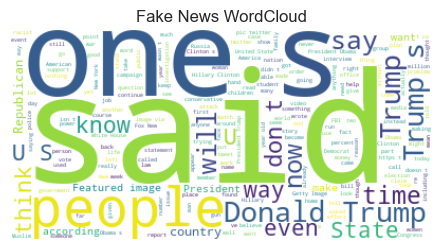

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(wCloudfake, interpolation="bilinear")
plt.axis("off")
plt.title("Fake News WordCloud")

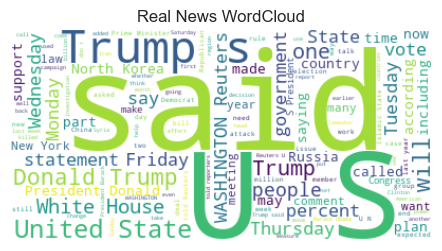

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(wCloudreal, interpolation="bilinear")
plt.axis("off")
plt.title("Real News WordCloud")
plt.show()